# Consumer Complaint Classification
### End-to-end NLP project: SimpleRNN vs. LSTM vs. GRU vs. fine-tuned Transformer

This notebook is designed to run on **Kaggle** with:

**Consumer Complaints Dataset for NLP**  
`shashwatwork/consume-complaints-dataset-fo-nlp`

## Project output
1. Dataset exploration and class-distribution analysis.
2. Text preprocessing and sequence preparation.
3. SimpleRNN, LSTM, and GRU models trained from scratch.
4. A fine-tuned Hugging Face Transformer.
5. Accuracy, precision, recall, macro/weighted F1, classification reports, and confusion matrices.
6. A fair comparison table and error analysis.
7. A Gradio web application returning category and confidence.
8. Saved models and artifacts under `/kaggle/working/`.

> **Recommended:** enable a Kaggle GPU and Internet access.

## Brief theory: NLP, RNN, and project terminology

### Natural Language Processing (NLP)
NLP enables computers to process, represent, understand, and generate human language. In this project, NLP converts a written complaint into numerical features so that a model can predict its financial-product category.

### Text classification
Text classification assigns one label to a complete document:

\[
\text{complaint narrative} \longrightarrow \text{product/category}
\]

### Recurrent Neural Network (RNN)
An RNN processes a sequence one token at a time while carrying a hidden state:

\[
h_t = \tanh(W_xx_t + W_hh_{t-1} + b)
\]

The hidden state acts as memory. A basic RNN can struggle with long-term dependencies because of vanishing or exploding gradients.

### SimpleRNN
The basic recurrent layer. It is a useful baseline but usually has weaker long-range memory than LSTM and GRU.

### LSTM
Long Short-Term Memory uses a cell state plus input, forget, and output gates. The gates regulate what is stored, forgotten, and exposed, helping with longer dependencies.

### GRU
Gated Recurrent Unit uses update and reset gates. It has fewer parameters than LSTM and often gives similar performance with faster training.

### Transformer
A Transformer uses self-attention rather than recurrence. It can relate each token to other relevant tokens and can be trained in parallel. A pretrained Transformer contains general language knowledge before task-specific training.

### Fine-tuning
Fine-tuning continues training a pretrained model on a smaller task-specific dataset. Here, `distilbert-base-uncased` is adapted to complaint categories.

| Term | Meaning |
|---|---|
| Corpus / dataset | Collection of complaint narratives and labels. |
| Token | A word, word piece, or symbol produced by a tokenizer. |
| Vocabulary | Set of token IDs known to the tokenizer. |
| Tokenization | Converting text into tokens and integer IDs. |
| Sequence | Ordered list of token IDs for one complaint. |
| Padding | Adding padding tokens so batch inputs have equal length. |
| Truncation | Cutting text beyond the selected maximum length. |
| Embedding | Learned dense vector representing a token. |
| Hidden state | RNN summary of the sequence processed so far. |
| Epoch | One complete pass over the training data. |
| Batch | Subset processed before one weight update. |
| Learning rate | Optimizer step size. |
| Logits | Raw class scores before softmax. |
| Softmax | Converts scores into class probabilities. |
| Confidence | Largest predicted probability; it may not be perfectly calibrated. |
| Class imbalance | Some categories contain many more records than others. |
| Class weight | Extra loss weight given to underrepresented categories. |
| Accuracy | Fraction of all predictions that are correct. |
| Precision | Of predictions for a class, the fraction that are correct. |
| Recall | Of true examples of a class, the fraction detected. |
| F1-score | Harmonic mean of precision and recall. |
| Macro F1 | Mean F1 with every class weighted equally. |
| Weighted F1 | Mean F1 weighted by class support. |
| Confusion matrix | True classes versus predicted classes. |
| Overfitting | Strong training performance but weak validation/test performance. |
| Dropout | Random deactivation used to reduce overfitting. |
| Early stopping | Stops when validation performance stops improving. |
| Inference | Classifying a new complaint with a trained model. |

**Preprocessing note:** aggressive stop-word removal and stemming can remove useful context. They are configurable for the RNN models and avoided for the pretrained Transformer.

## 1. Kaggle setup
1. Create a Kaggle notebook.
2. Select **Add Input**.
3. Search for `Consumer Complaints Dataset for NLP`.
4. Add the dataset by `shashwatwork`.
5. Enable a GPU in Notebook options.
6. Enable Internet for the Hugging Face model download.
7. Run all cells in order.

In [1]:
# Install/update libraries needed by the Transformer and deployment sections.
!pip -q install -U "transformers>=4.46,<5" "datasets>=2.20,<4" "accelerate>=0.34,<2" "gradio>=5,<7"

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 89.0 MB/s eta 0:00:00:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 491.5/491.5 kB 21.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 20.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.3/32.3 MB 56.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.3/116.3 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 27.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.6/73.6 kB 4.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.29.0 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.

In [2]:
import os
import re
import gc
import glob
import json
import random
import inspect
import shutil
import warnings
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    accuracy_score,
    precision_recall_fscore_support,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

SEED = 42
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow:", tf.__version__)
print("GPU devices:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU devices: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [3]:
import torch
import tensorflow as tf
import transformers
import accelerate
import gradio

print("PyTorch:", torch.__version__)
print("TensorFlow:", tf.__version__)
print("Transformers:", transformers.__version__)
print("Accelerate:", accelerate.__version__)
print("Gradio:", gradio.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch: 2.10.0+cu128
TensorFlow: 2.20.0
Transformers: 4.57.6
Accelerate: 1.14.0
Gradio: 6.17.3
GPU available: True


In [4]:
import datasets
from transformers import (
    Trainer,
    TrainingArguments,
    AutoTokenizer,
    AutoModelForSequenceClassification,
)

print("Datasets:", datasets.__version__)
print("Transformer components imported successfully.")
print("You can continue with the current notebook.")

Datasets: 3.6.0
Transformer components imported successfully.
You can continue with the current notebook.


## 2. Configuration
The default sample size makes the four-model comparison practical on a Kaggle GPU. Increase `MAX_ROWS` after the complete pipeline works.

In [5]:
MAX_ROWS = 60_000
MIN_CLASS_ROWS = 100
CSV_CHUNK_SIZE = 100_000
SAMPLE_PER_CHUNK = 8_000

TEST_SIZE = 0.15
VALIDATION_SIZE = 0.15

VOCAB_SIZE = 30_000
EMBEDDING_DIM = 128
RNN_UNITS = 64
MAX_SEQUENCE_CAP = 220
RNN_BATCH_SIZE = 256
RNN_EPOCHS = 8

REMOVE_STOPWORDS_FOR_RNN = False
APPLY_STEMMING_FOR_RNN = False

TRANSFORMER_MODEL_NAME = "distilbert-base-uncased"
TRANSFORMER_MAX_LENGTH = 192
TRANSFORMER_EPOCHS = 2
TRANSFORMER_BATCH_SIZE = 16
TRANSFORMER_GRADIENT_ACCUMULATION = 2

WORKING_DIR = Path("/kaggle/working/consumer_complaint_project")
WORKING_DIR.mkdir(parents=True, exist_ok=True)
print("Artifacts directory:", WORKING_DIR)

Artifacts directory: /kaggle/working/consumer_complaint_project


## 3. Find and load the complaint dataset

In [6]:
TEXT_CANDIDATES = [
    "consumer complaint narrative",
    "complaint narrative",
    "consumer_complaint_narrative",
    "complaint_text",
    "narrative",
    "complaint",
]
LABEL_CANDIDATES = [
    "product",
    "category",
    "complaint category",
    "complaint_category",
    "label",
]

def normalized_name(name):
    return re.sub(r"[^a-z0-9]+", " ", str(name).strip().lower()).strip()

def choose_column(columns, candidates):
    normalized_to_original = {normalized_name(c): c for c in columns}
    for candidate in candidates:
        key = normalized_name(candidate)
        if key in normalized_to_original:
            return normalized_to_original[key]
    for original in columns:
        n = normalized_name(original)
        for candidate in candidates:
            c = normalized_name(candidate)
            if c in n or n in c:
                return original
    return None

def inspect_csv_files(root="/kaggle/input"):
    csv_files = sorted(glob.glob(f"{root}/**/*.csv", recursive=True))
    if not csv_files:
        raise FileNotFoundError(
            "No CSV found under /kaggle/input. Add the dataset as a notebook input."
        )

    inspections = []
    for path in csv_files:
        try:
            preview = pd.read_csv(path, nrows=3, encoding_errors="ignore")
            inspections.append(
                {
                    "path": path,
                    "columns": list(preview.columns),
                    "text_col": choose_column(preview.columns, TEXT_CANDIDATES),
                    "label_col": choose_column(preview.columns, LABEL_CANDIDATES),
                }
            )
        except Exception as exc:
            inspections.append(
                {"path": path, "columns": [], "text_col": None, "label_col": None, "error": str(exc)}
            )

    candidates = [x for x in inspections if x["text_col"] and x["label_col"]]
    if not candidates:
        display(pd.DataFrame(inspections)[["path", "columns"]])
        raise ValueError(
            "No suitable text/label pair detected. Set DATA_PATH, TEXT_COLUMN, "
            "and LABEL_COLUMN manually after inspecting the table."
        )
    return candidates[0], inspections

selected, csv_inspections = inspect_csv_files()
DATA_PATH = selected["path"]
TEXT_COLUMN = selected["text_col"]
LABEL_COLUMN = selected["label_col"]

print("Selected file:", DATA_PATH)
print("Text column:", TEXT_COLUMN)
print("Label column:", LABEL_COLUMN)

Selected file: /kaggle/input/datasets/shashwatwork/consume-complaints-dataset-fo-nlp/complaints_processed.csv
Text column: narrative
Label column: product


In [7]:
def stream_counts_and_sample(
    csv_path,
    text_column,
    label_column,
    chunk_size=100_000,
    sample_per_chunk=8_000,
    seed=42,
):
    """Count labels over the full file and retain a manageable text sample."""
    full_label_counts = Counter()
    sampled_chunks = []

    reader = pd.read_csv(
        csv_path,
        usecols=[text_column, label_column],
        chunksize=chunk_size,
        encoding_errors="ignore",
        low_memory=False,
    )

    for chunk_index, chunk in enumerate(reader):
        chunk = chunk.rename(columns={text_column: "text", label_column: "label"})
        chunk["label"] = chunk["label"].astype("string").str.strip()
        full_label_counts.update(chunk["label"].dropna().tolist())

        chunk = chunk.dropna(subset=["text", "label"])
        chunk["text"] = chunk["text"].astype(str).str.strip()
        chunk = chunk[(chunk["text"].str.len() > 10) & (chunk["label"].str.len() > 0)]
        chunk = chunk.drop_duplicates(subset=["text", "label"])

        take = min(sample_per_chunk, len(chunk))
        if take:
            sampled_chunks.append(chunk.sample(n=take, random_state=seed + chunk_index))

    if not sampled_chunks:
        raise ValueError("No usable complaint narratives were found.")

    sample_pool = pd.concat(sampled_chunks, ignore_index=True)
    sample_pool = sample_pool.drop_duplicates(subset=["text", "label"]).reset_index(drop=True)
    counts = pd.Series(full_label_counts, dtype="int64").sort_values(ascending=False)
    return sample_pool, counts

sample_pool, full_class_counts = stream_counts_and_sample(
    DATA_PATH,
    TEXT_COLUMN,
    LABEL_COLUMN,
    chunk_size=CSV_CHUNK_SIZE,
    sample_per_chunk=SAMPLE_PER_CHUNK,
    seed=SEED,
)

print(f"Sample pool rows: {len(sample_pool):,}")
print(f"Classes in full data: {len(full_class_counts):,}")
display(full_class_counts.rename("full_dataset_count").to_frame().head(30))
display(sample_pool.head())

Sample pool rows: 15,999
Classes in full data: 5


,full_dataset_count
credit_reporting,91179
debt_collection,23150
mortgages_and_loans,18990
credit_card,15566
retail_banking,13536


,label,text
0,credit_reporting,contacted numerous time concerning open instal...
1,credit_reporting,disputed account experian incorrect informatio...
2,credit_card,automated kyc account closure final warning gi...
3,credit_card,brought problem first progress car sent collec...
4,credit_card,hello ashley furniture company credit card syn...


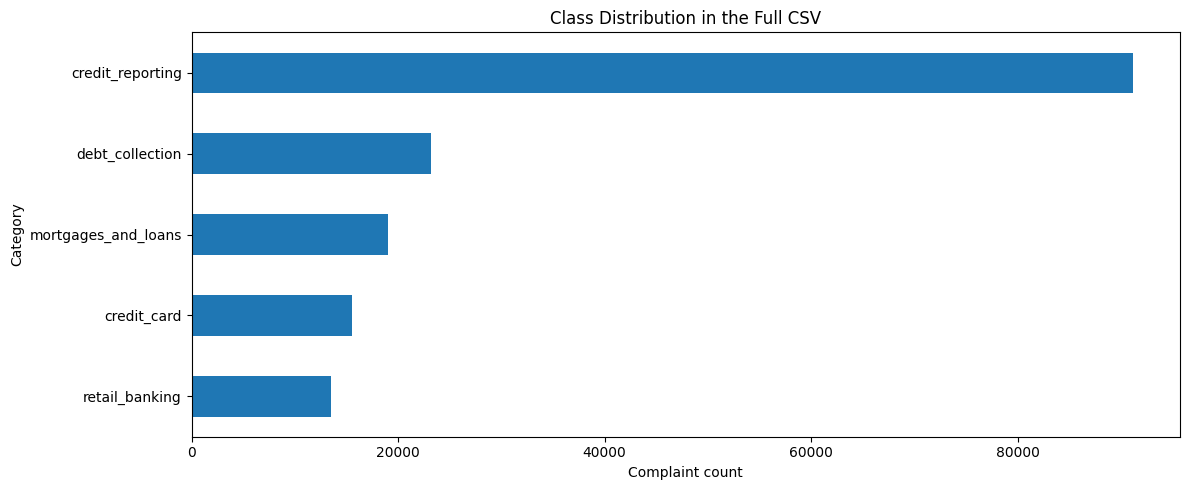

In [8]:
plt.figure(figsize=(12, max(5, 0.35 * len(full_class_counts))))
full_class_counts.sort_values().plot(kind="barh")
plt.title("Class Distribution in the Full CSV")
plt.xlabel("Complaint count")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

## 4. Clean, filter, and split
The notebook creates `text_rnn` for word-level recurrent models and a minimally normalized `text_transformer` for DistilBERT.

In [9]:
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

if APPLY_STEMMING_FOR_RNN:
    from nltk.stem import PorterStemmer
    stemmer = PorterStemmer()
else:
    stemmer = None

def clean_for_rnn(text):
    text = str(text).lower()
    text = re.sub(r"https?://\S+|www\.\S+", " ", text)
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"\b[xX]{2,}\b", " redacted ", text)
    text = re.sub(r"[^a-z'\s]", " ", text)
    tokens = [token for token in text.split() if len(token) > 1]
    if REMOVE_STOPWORDS_FOR_RNN:
        tokens = [token for token in tokens if token not in ENGLISH_STOP_WORDS]
    if stemmer is not None:
        tokens = [stemmer.stem(token) for token in tokens]
    return " ".join(tokens)

def clean_for_transformer(text):
    text = str(text)
    text = re.sub(r"\b[xX]{2,}\b", " redacted ", text)
    return re.sub(r"\s+", " ", text).strip()

pool_counts = sample_pool["label"].value_counts()
eligible_classes = pool_counts[pool_counts >= MIN_CLASS_ROWS].index
df = sample_pool[sample_pool["label"].isin(eligible_classes)].copy()

if len(df) > MAX_ROWS:
    df, _ = train_test_split(
        df,
        train_size=MAX_ROWS,
        stratify=df["label"],
        random_state=SEED,
    )

df["text_rnn"] = df["text"].map(clean_for_rnn)
df["text_transformer"] = df["text"].map(clean_for_transformer)
df = df[df["text_rnn"].str.len() > 0].reset_index(drop=True)

print(f"Modeling rows: {len(df):,}")
print(f"Modeling classes: {df['label'].nunique()}")
display(df["label"].value_counts().rename("modeling_count").to_frame())
display(df[["text", "text_rnn", "label"]].head(3))

Modeling rows: 15,999
Modeling classes: 5


,modeling_count
label,
credit_reporting,7199
debt_collection,2768
mortgages_and_loans,2403
credit_card,1851
retail_banking,1778


,text,text_rnn,label
0,contacted numerous time concerning open instal...,contacted numerous time concerning open instal...,credit_reporting
1,disputed account experian incorrect informatio...,disputed account experian incorrect informatio...,credit_reporting
2,automated kyc account closure final warning gi...,automated kyc account closure final warning gi...,credit_card


In [10]:
label_encoder = LabelEncoder()
df["label_id"] = label_encoder.fit_transform(df["label"])
class_names = label_encoder.classes_.tolist()
num_classes = len(class_names)

train_df, temp_df = train_test_split(
    df,
    test_size=TEST_SIZE + VALIDATION_SIZE,
    stratify=df["label_id"],
    random_state=SEED,
)
relative_test_size = TEST_SIZE / (TEST_SIZE + VALIDATION_SIZE)
val_df, test_df = train_test_split(
    temp_df,
    test_size=relative_test_size,
    stratify=temp_df["label_id"],
    random_state=SEED,
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df):,}")
print(f"Validation: {len(val_df):,}")
print(f"Test: {len(test_df):,}")
print(f"Classes: {num_classes}")
display(pd.DataFrame({"label_id": range(num_classes), "category": class_names}))

Train: 11,199
Validation: 2,400
Test: 2,400
Classes: 5


,label_id,category
0,0,credit_card
1,1,credit_reporting
2,2,debt_collection
3,3,mortgages_and_loans
4,4,retail_banking


In [11]:
classes_array = np.arange(num_classes)
class_weights_array = compute_class_weight(
    class_weight="balanced",
    classes=classes_array,
    y=train_df["label_id"].to_numpy(),
)
rnn_class_weights = {
    int(class_id): float(weight)
    for class_id, weight in zip(classes_array, class_weights_array)
}
display(pd.DataFrame({
    "label_id": classes_array,
    "category": class_names,
    "class_weight": class_weights_array,
}))

,label_id,category,class_weight
0,0,credit_card,1.728241
1,1,credit_reporting,0.444493
2,2,debt_collection,1.156324
3,3,mortgages_and_loans,1.331629
4,4,retail_banking,1.799036


## 5. Tokenization, numerical sequences, padding, and embedding preparation

In [12]:
rnn_tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token="<OOV>",
    filters="",
)
rnn_tokenizer.fit_on_texts(train_df["text_rnn"])

train_sequences = rnn_tokenizer.texts_to_sequences(train_df["text_rnn"])
val_sequences = rnn_tokenizer.texts_to_sequences(val_df["text_rnn"])
test_sequences = rnn_tokenizer.texts_to_sequences(test_df["text_rnn"])

train_lengths = np.array([len(sequence) for sequence in train_sequences])
MAX_LEN = int(np.percentile(train_lengths, 95))
MAX_LEN = max(40, min(MAX_LEN, MAX_SEQUENCE_CAP))

X_train = pad_sequences(train_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_val = pad_sequences(val_sequences, maxlen=MAX_LEN, padding="post", truncating="post")
X_test = pad_sequences(test_sequences, maxlen=MAX_LEN, padding="post", truncating="post")

y_train = train_df["label_id"].to_numpy()
y_val = val_df["label_id"].to_numpy()
y_test = test_df["label_id"].to_numpy()

effective_vocab_size = min(VOCAB_SIZE, len(rnn_tokenizer.word_index) + 1)
print("Effective vocabulary size:", effective_vocab_size)
print("Selected MAX_LEN:", MAX_LEN)
print("X_train shape:", X_train.shape)

Effective vocabulary size: 15852
Selected MAX_LEN: 220
X_train shape: (11199, 220)


In [18]:
# Use standalone Keras 3 consistently for all recurrent models.
import keras as k3
from keras import layers as k3_layers

print("Keras version:", k3.__version__)
print("Keras backend:", k3.backend.backend())

assert k3.backend.backend() == "tensorflow", (
    "Keras is not using the TensorFlow backend."
)

Keras version: 3.13.2
Keras backend: tensorflow


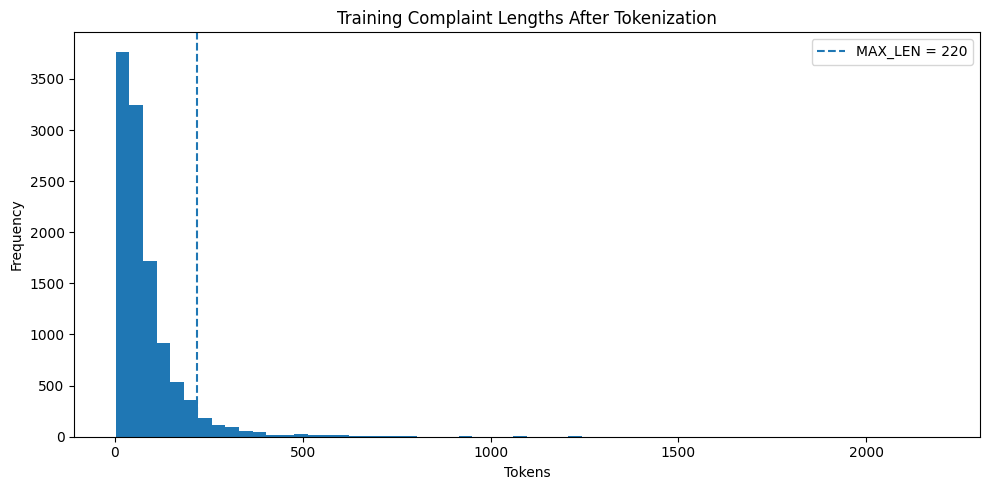

In [13]:
plt.figure(figsize=(10, 5))
plt.hist(train_lengths, bins=60)
plt.axvline(MAX_LEN, linestyle="--", label=f"MAX_LEN = {MAX_LEN}")
plt.title("Training Complaint Lengths After Tokenization")
plt.xlabel("Tokens")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 6. Shared evaluation functions

In [15]:
results = []
prediction_store = {}
history_store = {}
model_paths = {}

def evaluate_probabilities(model_name, y_true, probabilities):
    predictions = np.argmax(probabilities, axis=1)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        y_true, predictions, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        y_true, predictions, average="weighted", zero_division=0
    )
    row = {
        "model": model_name,
        "accuracy": accuracy_score(y_true, predictions),
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f_weighted,
    }
    global results
    results = [existing for existing in results if existing["model"] != model_name]
    results.append(row)
    prediction_store[model_name] = {
        "probabilities": probabilities,
        "predictions": predictions,
    }
    return row

def show_classification_report(model_name):
    predictions = prediction_store[model_name]["predictions"]
    report = classification_report(
        y_test,
        predictions,
        target_names=class_names,
        output_dict=True,
        zero_division=0,
    )
    display(pd.DataFrame(report).T)

def plot_confusion_matrix(model_name, normalize="true"):
    predictions = prediction_store[model_name]["predictions"]
    matrix = confusion_matrix(y_test, predictions, normalize=normalize)
    fig, ax = plt.subplots(figsize=(max(10, 0.7 * num_classes), max(8, 0.6 * num_classes)))
    ConfusionMatrixDisplay(matrix, display_labels=class_names).plot(
        ax=ax,
        xticks_rotation=90,
        values_format=".2f" if normalize else "d",
        colorbar=True,
    )
    ax.set_title(f"{model_name} Confusion Matrix")
    plt.tight_layout()
    plt.show()

def plot_training_history(model_name):
    history_df = pd.DataFrame(history_store[model_name].history)

    plt.figure(figsize=(9, 5))
    plt.plot(history_df.index + 1, history_df["loss"], marker="o", label="Training loss")
    plt.plot(history_df.index + 1, history_df["val_loss"], marker="o", label="Validation loss")
    plt.title(f"{model_name}: Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.plot(history_df.index + 1, history_df["accuracy"], marker="o", label="Training accuracy")
    plt.plot(history_df.index + 1, history_df["val_accuracy"], marker="o", label="Validation accuracy")
    plt.title(f"{model_name}: Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

## 7. Train SimpleRNN, LSTM, and GRU

In [19]:
def build_recurrent_model(cell_type):
    # Every model component below comes from the same Keras 3 package.
    inputs = k3.Input(
        shape=(MAX_LEN,),
        dtype="int32",
        name="token_ids",
    )

    x = k3_layers.Embedding(
        input_dim=effective_vocab_size,
        output_dim=EMBEDDING_DIM,
        mask_zero=True,
        name="embedding",
    )(inputs)

    x = k3_layers.SpatialDropout1D(0.25)(x)

    if cell_type == "SimpleRNN":
        x = k3_layers.SimpleRNN(
            RNN_UNITS,
            dropout=0.25,
            name="simple_rnn",
        )(x)

    elif cell_type == "LSTM":
        x = k3_layers.LSTM(
            RNN_UNITS,
            dropout=0.25,
            name="lstm",
        )(x)

    elif cell_type == "GRU":
        x = k3_layers.GRU(
            RNN_UNITS,
            dropout=0.25,
            name="gru",
        )(x)

    else:
        raise ValueError(f"Unsupported model type: {cell_type}")

    x = k3_layers.Dense(
        64,
        activation="relu",
        name="dense_features",
    )(x)

    x = k3_layers.Dropout(0.35)(x)

    outputs = k3_layers.Dense(
        num_classes,
        activation="softmax",
        name="class_probabilities",
    )(x)

    model = k3.Model(
        inputs=inputs,
        outputs=outputs,
        name=f"{cell_type}_classifier",
    )

    model.compile(
        optimizer=k3.optimizers.Adam(learning_rate=1e-3),
        loss=k3.losses.SparseCategoricalCrossentropy(),
        metrics=["accuracy"],
    )

    return model


def train_recurrent_model(cell_type):
    k3.backend.clear_session()

    model = build_recurrent_model(cell_type)
    model.summary()

    callbacks = [
        k3.callbacks.EarlyStopping(
            monitor="val_loss",
            patience=2,
            restore_best_weights=True,
            verbose=1,
        ),
        k3.callbacks.ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=1,
            min_lr=1e-5,
            verbose=1,
        ),
    ]

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=RNN_EPOCHS,
        batch_size=RNN_BATCH_SIZE,
        class_weight=rnn_class_weights,
        callbacks=callbacks,
        verbose=1,
    )

    probabilities = model.predict(
        X_test,
        batch_size=512,
        verbose=1,
    )

    metric_row = evaluate_probabilities(
        cell_type,
        y_test,
        probabilities,
    )

    path = (
        WORKING_DIR
        / f"{cell_type.lower()}_complaint_classifier.keras"
    )

    model.save(path)
    model_paths[cell_type] = str(path)
    history_store[cell_type] = history

    print("\nTest results:")
    display(pd.DataFrame([metric_row]).set_index("model"))

    plot_training_history(cell_type)

    del model
    k3.backend.clear_session()
    gc.collect()

In [20]:
test_model = build_recurrent_model("SimpleRNN")

test_output = test_model(
    np.zeros((2, MAX_LEN), dtype=np.int32),
    training=False,
)

print("Model test successful.")
print("Output shape:", test_output.shape)

del test_model
k3.backend.clear_session()

Model test successful.
Output shape: (2, 5)



TRAINING: SimpleRNN


Model: "SimpleRNN_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 220)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 220, 128)  │  2,029,056 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 220, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 220)       │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ simple_rnn          │ (None, 64)        │     12,352 │ spatial_dropout1… │
│ (SimpleRNN)         │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 64)        │      4,160 │ simple_rnn[0][0]  │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_probabilities │ (None, 5)         │        325 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,045,893 (7.80 MB)

 Trainable params: 2,045,893 (7.80 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
 3/44 ━━━━━━━━━━━━━━━━━━━━ 1s 44ms/step - accuracy: 0.1673 - loss: 1.6104

I0000 00:00:1784705667.106050     162 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


44/44 ━━━━━━━━━━━━━━━━━━━━ 12s 134ms/step - accuracy: 0.2438 - loss: 1.5169 - val_accuracy: 0.3054 - val_loss: 1.4885 - learning_rate: 0.0010
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.3986 - loss: 1.2174 - val_accuracy: 0.4408 - val_loss: 1.1974 - learning_rate: 0.0010
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.5926 - loss: 0.9809 - val_accuracy: 0.7158 - val_loss: 0.8241 - learning_rate: 0.0010
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7598 - loss: 0.6912 - val_accuracy: 0.7396 - val_loss: 0.7313 - learning_rate: 0.0010
Epoch 5/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8203 - loss: 0.5194 - val_accuracy: 0.7683 - val_loss: 0.6665 - learning_rate: 0.0010
Epoch 6/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8525 - loss: 0.4492
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8546 - loss: 0.4136 - val_accuracy: 0.7462 -

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
SimpleRNN,0.772083,0.753545,0.742944,0.746151,0.776498,0.772083,0.773001


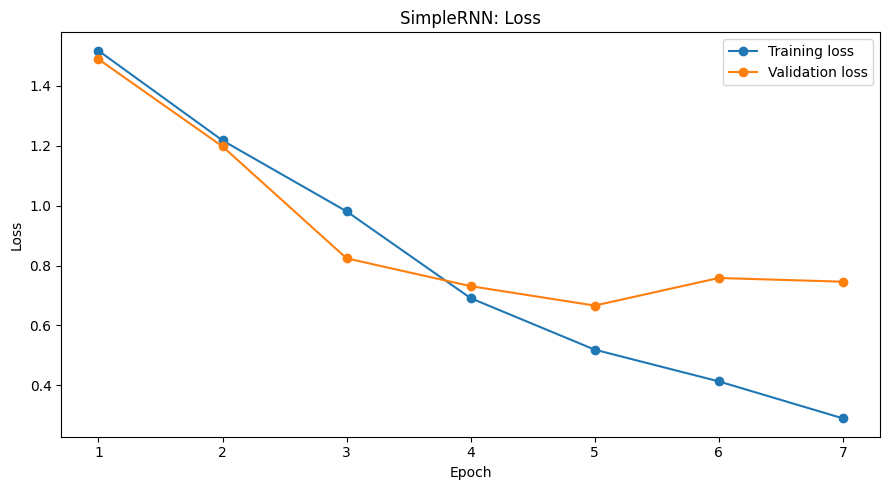

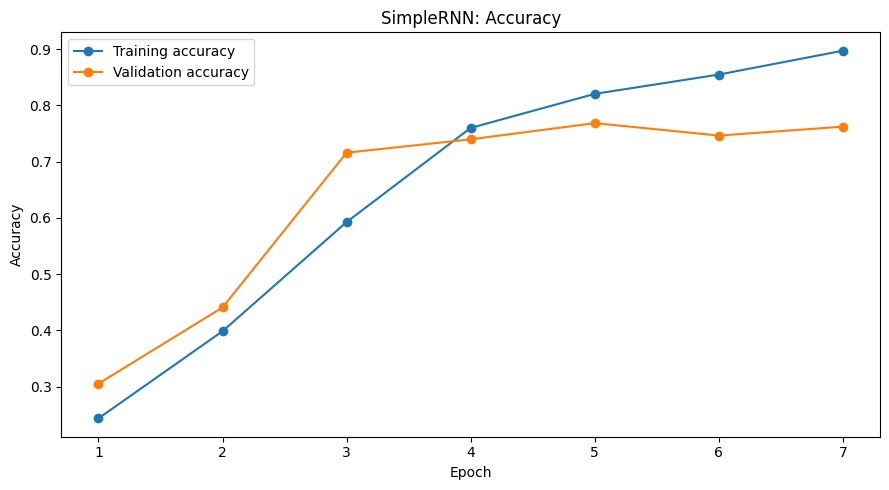


TRAINING: LSTM


Model: "LSTM_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 220)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 220, 128)  │  2,029,056 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 220, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 220)       │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 64)        │     49,408 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 64)        │      4,160 │ lstm[0][0]        │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_probabilities │ (None, 5)         │        325 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,082,949 (7.95 MB)

 Trainable params: 2,082,949 (7.95 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - accuracy: 0.4565 - loss: 1.4576 - val_accuracy: 0.5679 - val_loss: 1.1326 - learning_rate: 0.0010
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.5385 - loss: 1.1567 - val_accuracy: 0.6079 - val_loss: 0.9787 - learning_rate: 0.0010
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.6980 - loss: 0.8799 - val_accuracy: 0.7017 - val_loss: 0.8849 - learning_rate: 0.0010
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.7805 - loss: 0.6856 - val_accuracy: 0.7629 - val_loss: 0.7580 - learning_rate: 0.0010
Epoch 5/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.8180 - loss: 0.5981
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.8170 - loss: 0.5944 - val_accuracy: 0.7592 - val_loss: 0.8048 - learning_rate: 0.0010
Epoch 6/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.8426 - loss: 0.4928
Epoch 6: ReduceL

,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
LSTM,0.761667,0.731656,0.774099,0.746062,0.784864,0.761667,0.765967


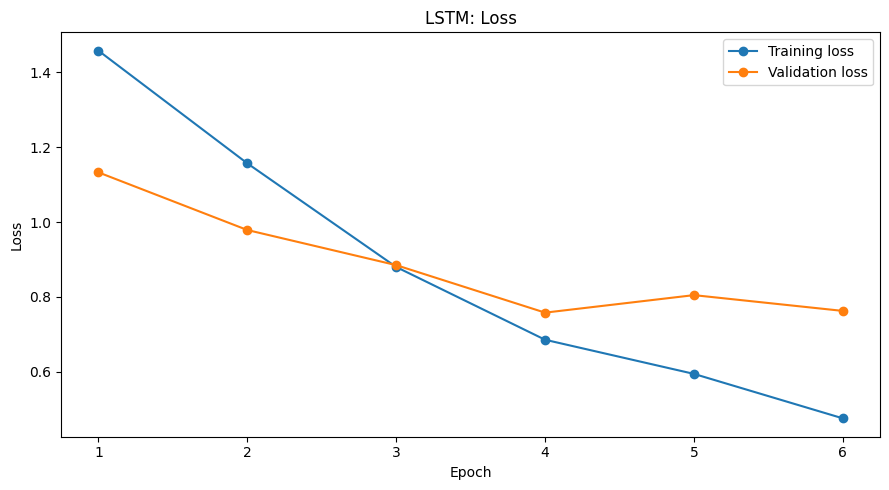

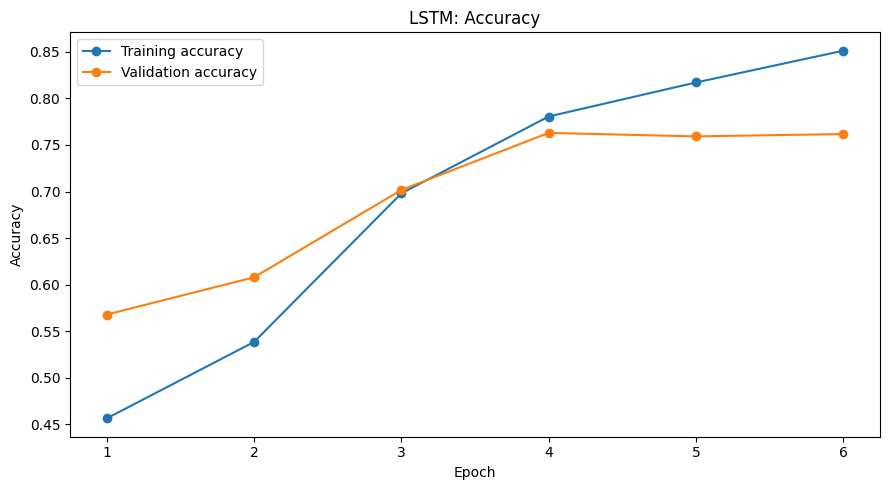


TRAINING: GRU


Model: "GRU_classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ token_ids           │ (None, 220)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding           │ (None, 220, 128)  │  2,029,056 │ token_ids[0][0]   │
│ (Embedding)         │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ spatial_dropout1d   │ (None, 220, 128)  │          0 │ embedding[0][0]   │
│ (SpatialDropout1D)  │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 220)       │          0 │ token_ids[0][0]   │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ gru (GRU)           │ (None, 64)        │     37,248 │ spatial_dropout1… │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_features      │ (None, 64)        │      4,160 │ gru[0][0]         │
│ (Dense)             │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 64)        │          0 │ dense_features[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ class_probabilities │ (None, 5)         │        325 │ dropout[0][0]     │
│ (Dense)             │                   │            │                   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 2,070,789 (7.90 MB)

 Trainable params: 2,070,789 (7.90 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 3s 31ms/step - accuracy: 0.3170 - loss: 1.5394 - val_accuracy: 0.5567 - val_loss: 1.1274 - learning_rate: 0.0010
Epoch 2/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.4923 - loss: 1.1474 - val_accuracy: 0.5733 - val_loss: 1.0415 - learning_rate: 0.0010
Epoch 3/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.6507 - loss: 0.8367 - val_accuracy: 0.6938 - val_loss: 0.8006 - learning_rate: 0.0010
Epoch 4/8
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.7851 - loss: 0.5925 - val_accuracy: 0.7446 - val_loss: 0.7379 - learning_rate: 0.0010
Epoch 5/8
43/44 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8160 - loss: 0.5302
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8271 - loss: 0.4994 - val_accuracy: 0.7592 - val_loss: 0.8001 - learning_rate: 0.0010
Epoch 6/8
41/44 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8604 - loss: 0.4315
Epoch 6: ReduceL

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/stepWARNING:tensorflow:5 out of the last 11 calls to <function TensorFlowTrainer.make_predict_function.<locals>.one_step_on_data_distributed at 0x78d488222de0> triggered tf.function retracing. Tracing is expensive and the excessive number of tracings could be due to (1) creating @tf.function repeatedly in a loop, (2) passing tensors with different shapes, (3) passing Python objects instead of tensors. For (1), please define your @tf.function outside of the loop. For (2), @tf.function has reduce_retracing=True option that can avoid unnecessary retracing. For (3), please refer to https://www.tensorflow.org/guide/function#controlling_retracing and https://www.tensorflow.org/api_docs/python/tf/function for  more details.


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step

Test results:


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
GRU,0.74375,0.699602,0.727374,0.703176,0.756206,0.74375,0.742543


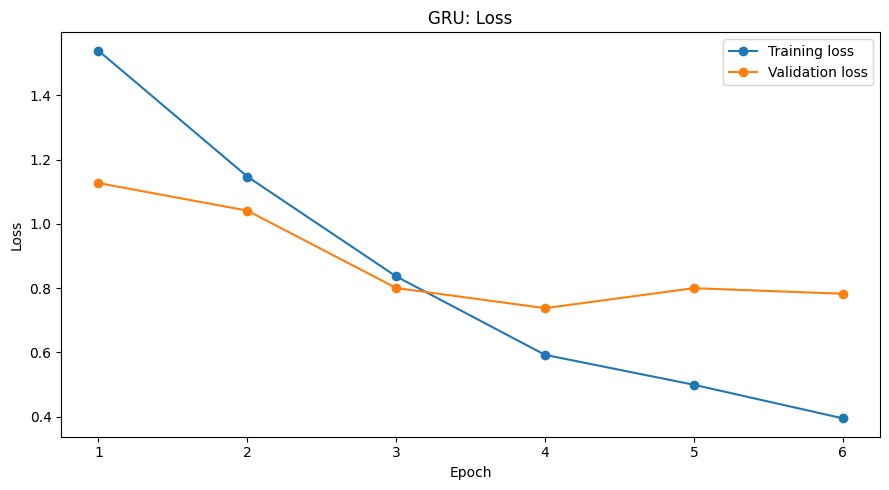

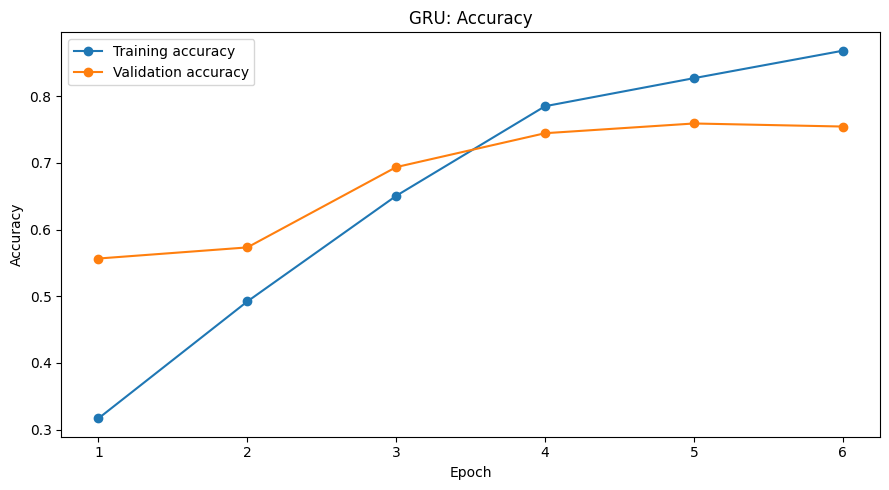

In [21]:
for architecture in ["SimpleRNN", "LSTM", "GRU"]:
    print("\n" + "=" * 90)
    print("TRAINING:", architecture)
    print("=" * 90)

    train_recurrent_model(architecture)


SimpleRNN


,precision,recall,f1-score,support
credit_card,0.625767,0.733813,0.675497,278.000000
credit_reporting,0.833181,0.841667,0.837402,1080.000000
debt_collection,0.677570,0.698795,0.688019,415.000000
mortgages_and_loans,0.786378,0.703601,0.742690,361.000000
retail_banking,0.844828,0.736842,0.787149,266.000000
accuracy,0.772083,0.772083,0.772083,0.772083
macro avg,0.753545,0.742944,0.746151,2400.000000
weighted avg,0.776498,0.772083,0.773001,2400.000000


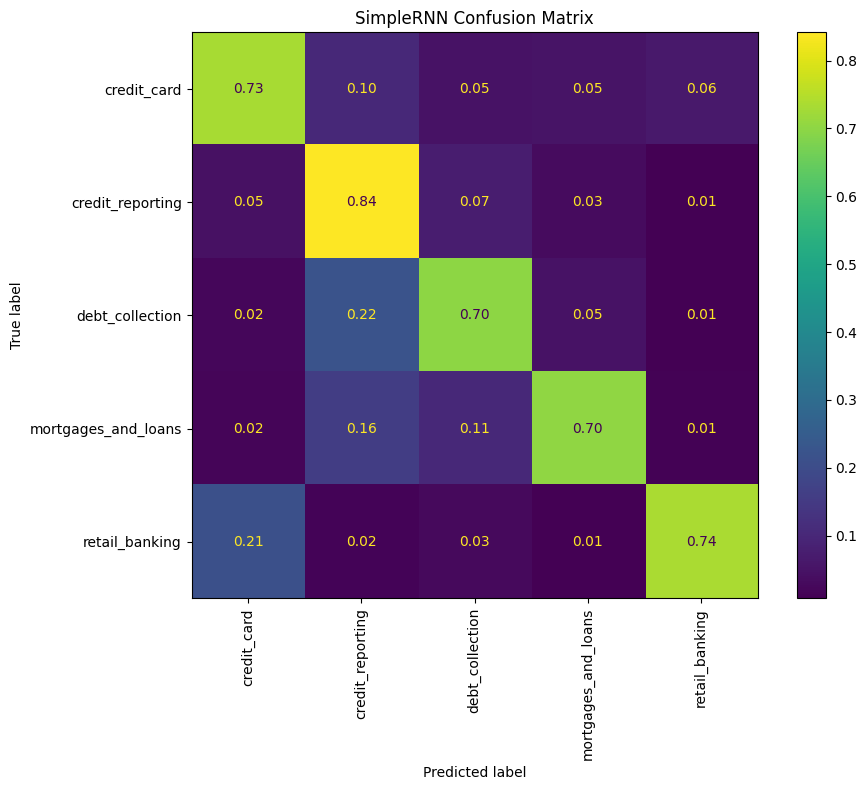


LSTM


,precision,recall,f1-score,support
credit_card,0.609231,0.712230,0.656716,278.000000
credit_reporting,0.906321,0.743519,0.816887,1080.000000
debt_collection,0.608209,0.785542,0.685594,415.000000
mortgages_and_loans,0.788344,0.711911,0.748180,361.000000
retail_banking,0.746177,0.917293,0.822934,266.000000
accuracy,0.761667,0.761667,0.761667,0.761667
macro avg,0.731656,0.774099,0.746062,2400.000000
weighted avg,0.784864,0.761667,0.765967,2400.000000


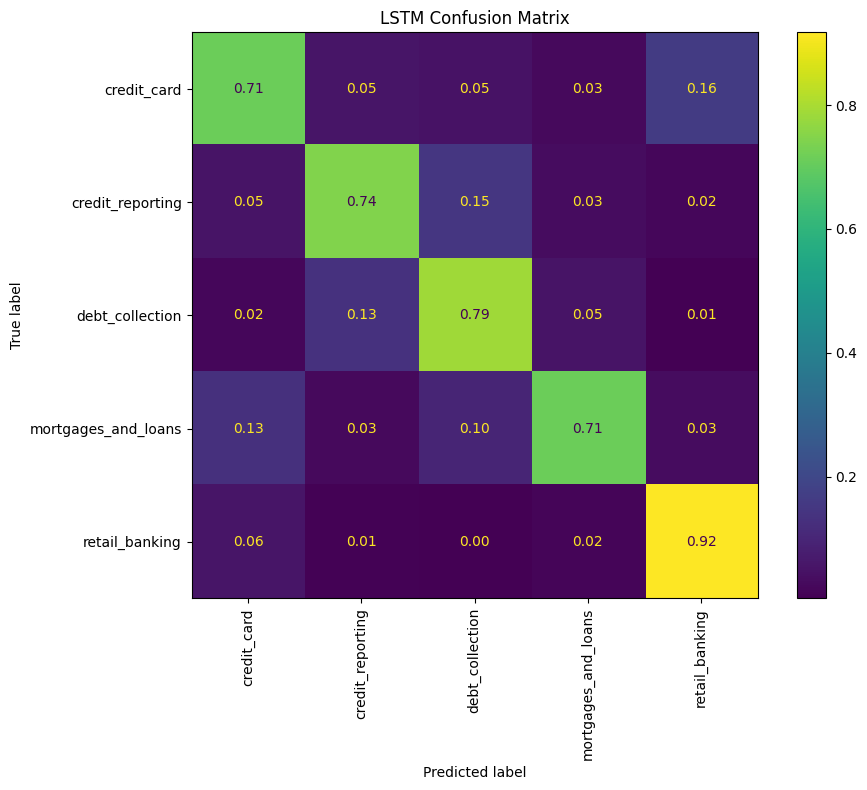


GRU


,precision,recall,f1-score,support
credit_card,0.595960,0.424460,0.495798,278.00000
credit_reporting,0.873684,0.768519,0.817734,1080.00000
debt_collection,0.625243,0.775904,0.692473,415.00000
mortgages_and_loans,0.767705,0.750693,0.759104,361.00000
retail_banking,0.635417,0.917293,0.750769,266.00000
accuracy,0.743750,0.743750,0.743750,0.74375
macro avg,0.699602,0.727374,0.703176,2400.00000
weighted avg,0.756206,0.743750,0.742543,2400.00000


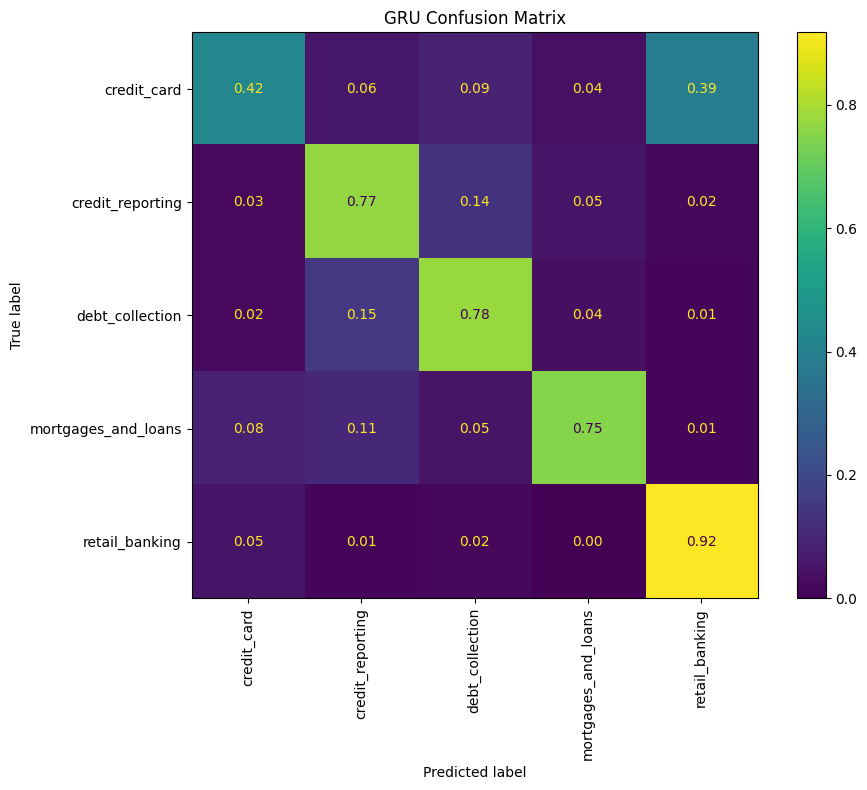

In [22]:
for architecture in ["SimpleRNN", "LSTM", "GRU"]:
    print("\n" + "=" * 90)
    print(architecture)
    print("=" * 90)
    show_classification_report(architecture)
    plot_confusion_matrix(architecture, normalize="true")

## 8. Fine-tune a Hugging Face Transformer
DistilBERT uses minimally processed natural text. A custom weighted loss helps underrepresented categories.

In [23]:
import torch
import transformers
import datasets
from torch import nn
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    TrainingArguments,
    Trainer,
)

print("PyTorch:", torch.__version__)
print("Transformers:", transformers.__version__)
print("Datasets:", datasets.__version__)
print("CUDA available:", torch.cuda.is_available())

id2label = {index: label for index, label in enumerate(class_names)}
label2id = {label: index for index, label in enumerate(class_names)}

hf_tokenizer = AutoTokenizer.from_pretrained(TRANSFORMER_MODEL_NAME)

def to_hf_dataset(frame):
    temp = frame[["text_transformer", "label_id"]].rename(
        columns={"text_transformer": "text", "label_id": "labels"}
    )
    return Dataset.from_pandas(temp, preserve_index=False)

hf_train = to_hf_dataset(train_df)
hf_val = to_hf_dataset(val_df)
hf_test = to_hf_dataset(test_df)

def tokenize_batch(batch):
    return hf_tokenizer(
        batch["text"],
        truncation=True,
        max_length=TRANSFORMER_MAX_LENGTH,
    )

hf_train = hf_train.map(tokenize_batch, batched=True, remove_columns=["text"])
hf_val = hf_val.map(tokenize_batch, batched=True, remove_columns=["text"])
hf_test = hf_test.map(tokenize_batch, batched=True, remove_columns=["text"])

data_collator = DataCollatorWithPadding(tokenizer=hf_tokenizer)

transformer_model = AutoModelForSequenceClassification.from_pretrained(
    TRANSFORMER_MODEL_NAME,
    num_labels=num_classes,
    id2label=id2label,
    label2id=label2id,
)

PyTorch: 2.10.0+cu128
Transformers: 4.57.6
Datasets: 3.6.0
CUDA available: True


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/11199 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

Map:   0%|          | 0/2400 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [24]:
transformer_class_weights = torch.tensor(
    compute_class_weight(
        class_weight="balanced",
        classes=np.arange(num_classes),
        y=y_train,
    ),
    dtype=torch.float32,
)

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        labels = inputs.get("labels")
        model_inputs = {key: value for key, value in inputs.items() if key != "labels"}
        outputs = model(**model_inputs)
        logits = outputs.logits
        loss_fn = nn.CrossEntropyLoss(weight=self.class_weights.to(logits.device))
        loss = loss_fn(logits, labels)
        return (loss, outputs) if return_outputs else loss

def compute_transformer_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=1)
    p_macro, r_macro, f_macro, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    p_weighted, r_weighted, f_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )
    return {
        "accuracy": accuracy_score(labels, predictions),
        "precision_macro": p_macro,
        "recall_macro": r_macro,
        "f1_macro": f_macro,
        "precision_weighted": p_weighted,
        "recall_weighted": r_weighted,
        "f1_weighted": f_weighted,
    }

argument_kwargs = dict(
    output_dir=str(WORKING_DIR / "transformer_checkpoints"),
    num_train_epochs=TRANSFORMER_EPOCHS,
    learning_rate=2e-5,
    per_device_train_batch_size=TRANSFORMER_BATCH_SIZE,
    per_device_eval_batch_size=TRANSFORMER_BATCH_SIZE * 2,
    gradient_accumulation_steps=TRANSFORMER_GRADIENT_ACCUMULATION,
    weight_decay=0.01,
    warmup_ratio=0.1,
    logging_steps=100,
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    save_total_limit=1,
    report_to="none",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    data_seed=SEED,
)

training_args_signature = inspect.signature(TrainingArguments.__init__).parameters
if "eval_strategy" in training_args_signature:
    argument_kwargs["eval_strategy"] = "epoch"
else:
    argument_kwargs["evaluation_strategy"] = "epoch"

training_args = TrainingArguments(**argument_kwargs)

trainer_kwargs = dict(
    model=transformer_model,
    args=training_args,
    train_dataset=hf_train,
    eval_dataset=hf_val,
    data_collator=data_collator,
    compute_metrics=compute_transformer_metrics,
    class_weights=transformer_class_weights,
)

trainer_signature = inspect.signature(Trainer.__init__).parameters
if "processing_class" in trainer_signature:
    trainer_kwargs["processing_class"] = hf_tokenizer
else:
    trainer_kwargs["tokenizer"] = hf_tokenizer

trainer = WeightedTrainer(**trainer_kwargs)

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,1.267500,0.641155,0.776250,0.742758,0.786635,0.759693,0.792327,0.776250,0.778627
2,0.573000,0.579493,0.785417,0.753886,0.801868,0.773224,0.803175,0.785417,0.788258


,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
model,,,,,,,
Transformer,0.796667,0.772535,0.818102,0.790845,0.813881,0.796667,0.79939


,precision,recall,f1-score,support
credit_card,0.706840,0.780576,0.741880,278.000000
credit_reporting,0.919774,0.753704,0.828499,1080.000000
debt_collection,0.658730,0.800000,0.722524,415.000000
mortgages_and_loans,0.742243,0.861496,0.797436,361.000000
retail_banking,0.835088,0.894737,0.863884,266.000000
accuracy,0.796667,0.796667,0.796667,0.796667
macro avg,0.772535,0.818102,0.790845,2400.000000
weighted avg,0.813881,0.796667,0.799390,2400.000000


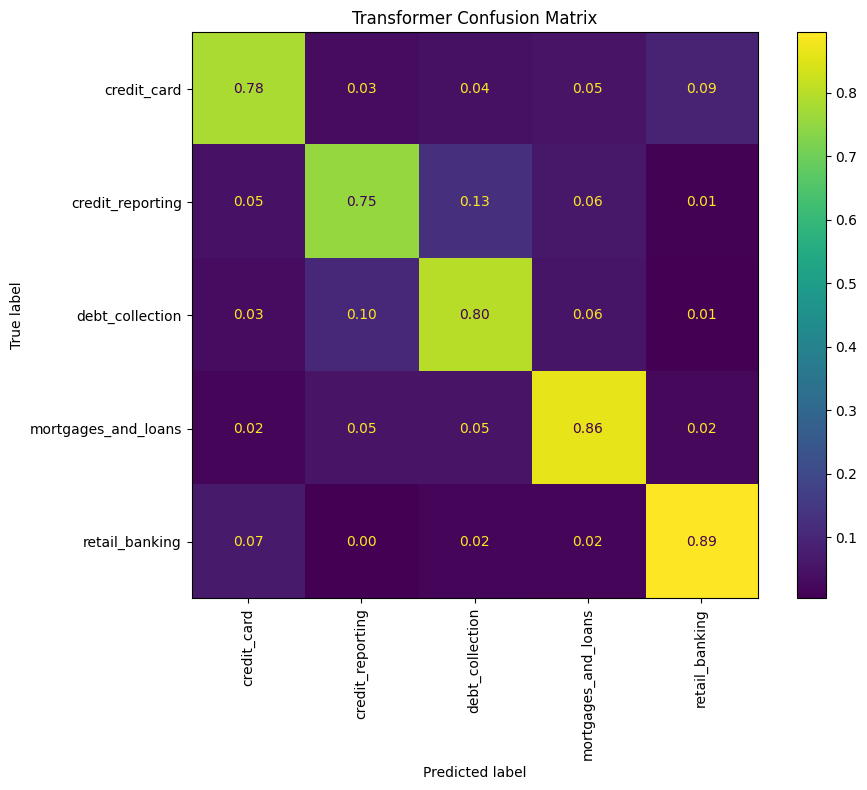

In [25]:
trainer.train()

prediction_output = trainer.predict(hf_test)
transformer_logits = prediction_output.predictions
transformer_probabilities = torch.softmax(
    torch.tensor(transformer_logits), dim=1
).cpu().numpy()

transformer_metrics = evaluate_probabilities(
    "Transformer", y_test, transformer_probabilities
)
display(pd.DataFrame([transformer_metrics]).set_index("model"))

TRANSFORMER_SAVE_PATH = WORKING_DIR / "fine_tuned_transformer"
trainer.save_model(str(TRANSFORMER_SAVE_PATH))
hf_tokenizer.save_pretrained(str(TRANSFORMER_SAVE_PATH))
model_paths["Transformer"] = str(TRANSFORMER_SAVE_PATH)

show_classification_report("Transformer")
plot_confusion_matrix("Transformer", normalize="true")

## 9. Compare all four models

,model,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted
0,Transformer,0.7967,0.7725,0.8181,0.7908,0.8139,0.7967,0.7994
1,SimpleRNN,0.7721,0.7535,0.7429,0.7462,0.7765,0.7721,0.7730
2,LSTM,0.7617,0.7317,0.7741,0.7461,0.7849,0.7617,0.7660
3,GRU,0.7438,0.6996,0.7274,0.7032,0.7562,0.7438,0.7425


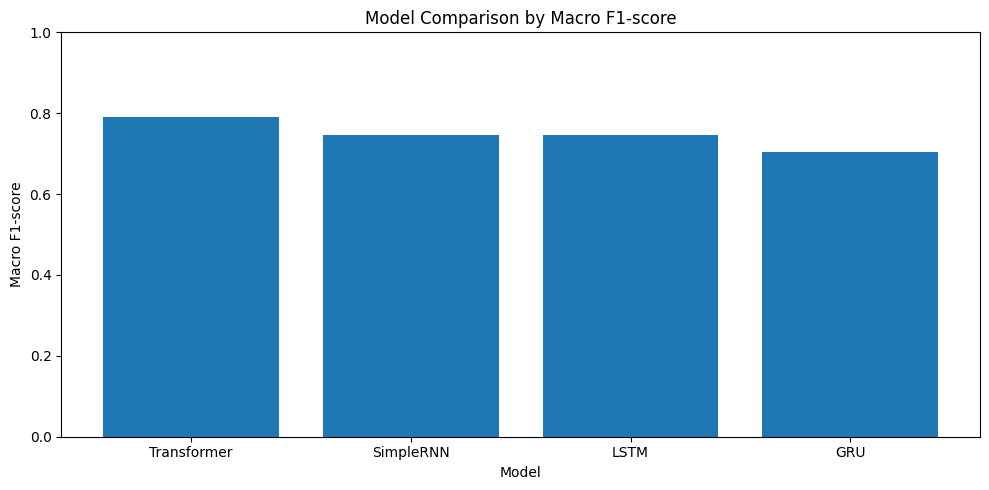

Best model by macro F1: Transformer


In [26]:
results_df = (
    pd.DataFrame(results)
    .sort_values(["f1_macro", "f1_weighted", "accuracy"], ascending=False)
    .reset_index(drop=True)
)
display(results_df.style.format({
    "accuracy": "{:.4f}",
    "precision_macro": "{:.4f}",
    "recall_macro": "{:.4f}",
    "f1_macro": "{:.4f}",
    "precision_weighted": "{:.4f}",
    "recall_weighted": "{:.4f}",
    "f1_weighted": "{:.4f}",
}))
results_df.to_csv(WORKING_DIR / "model_comparison.csv", index=False)

plt.figure(figsize=(10, 5))
plt.bar(results_df["model"], results_df["f1_macro"])
plt.ylim(0, 1)
plt.title("Model Comparison by Macro F1-score")
plt.xlabel("Model")
plt.ylabel("Macro F1-score")
plt.tight_layout()
plt.show()

BEST_MODEL_NAME = results_df.iloc[0]["model"]
print("Best model by macro F1:", BEST_MODEL_NAME)

### How to discuss the results
Use **macro F1** as the primary score because each category receives equal importance under class imbalance. Also report accuracy and weighted F1.

Discuss:
1. The best model and its macro F1.
2. Easy and difficult categories.
3. Minority-category recall.
4. Whether LSTM/GRU improved over SimpleRNN.
5. Whether the pretrained Transformer improved over models from scratch.
6. Quality versus training time, model size, and inference speed.

Do not state final metrics until the cells have actually run.

## 10. Inspect wrong predictions

In [27]:
best_predictions = prediction_store[BEST_MODEL_NAME]["predictions"]
best_confidences = prediction_store[BEST_MODEL_NAME]["probabilities"].max(axis=1)

error_analysis = test_df[["text", "label"]].copy()
error_analysis["predicted_label"] = label_encoder.inverse_transform(best_predictions)
error_analysis["confidence"] = best_confidences
error_analysis["correct"] = error_analysis["label"] == error_analysis["predicted_label"]

display(
    error_analysis[~error_analysis["correct"]]
    .sort_values("confidence", ascending=False)
    .head(20)
)
error_analysis.to_csv(WORKING_DIR / "best_model_error_analysis.csv", index=False)

,text,label,predicted_label,confidence,correct
506,person acted lending tree representative put f...,mortgages_and_loans,retail_banking,0.927128,False
370,phh mortgage mailed escrow statement according...,debt_collection,mortgages_and_loans,0.924639,False
2223,lender lender representative tried gain access...,debt_collection,mortgages_and_loans,0.923719,False
280,company closed account response previous compl...,credit_card,retail_banking,0.922536,False
1421,bank horrible close account without notice rea...,credit_card,retail_banking,0.922308,False
2198,opened checking account first bank made transa...,credit_reporting,retail_banking,0.922069,False
1282,closed well fargo credit card found recently w...,credit_reporting,credit_card,0.921162,False
2220,transunion failed communicate result investiga...,debt_collection,credit_reporting,0.919730,False
1164,open capital one account sent venture card acc...,credit_reporting,credit_card,0.919588,False
1764,citibank na sd bank card sent notice account p...,credit_reporting,credit_card,0.918447,False


## 11. Save preprocessing objects and configuration

In [28]:
import joblib

with open(WORKING_DIR / "rnn_tokenizer.json", "w", encoding="utf-8") as file:
    file.write(rnn_tokenizer.to_json())

joblib.dump(label_encoder, WORKING_DIR / "label_encoder.joblib")

experiment_config = {
    "seed": SEED,
    "data_path": DATA_PATH,
    "text_column": TEXT_COLUMN,
    "label_column": LABEL_COLUMN,
    "max_rows": MAX_ROWS,
    "min_class_rows": MIN_CLASS_ROWS,
    "num_classes": num_classes,
    "class_names": class_names,
    "vocab_size": VOCAB_SIZE,
    "effective_vocab_size": effective_vocab_size,
    "embedding_dim": EMBEDDING_DIM,
    "rnn_units": RNN_UNITS,
    "max_len": MAX_LEN,
    "transformer_model_name": TRANSFORMER_MODEL_NAME,
    "transformer_max_length": TRANSFORMER_MAX_LENGTH,
    "best_model": BEST_MODEL_NAME,
    "model_paths": model_paths,
}
with open(WORKING_DIR / "experiment_config.json", "w", encoding="utf-8") as file:
    json.dump(experiment_config, file, indent=2, ensure_ascii=False)

print("Saved files:")
for path in sorted(WORKING_DIR.rglob("*")):
    if path.is_file():
        print(path.relative_to(WORKING_DIR))

Saved files:
best_model_error_analysis.csv
experiment_config.json
fine_tuned_transformer/config.json
fine_tuned_transformer/model.safetensors
fine_tuned_transformer/special_tokens_map.json
fine_tuned_transformer/tokenizer.json
fine_tuned_transformer/tokenizer_config.json
fine_tuned_transformer/training_args.bin
fine_tuned_transformer/vocab.txt
gru_complaint_classifier.keras
label_encoder.joblib
lstm_complaint_classifier.keras
model_comparison.csv
rnn_tokenizer.json
simplernn_complaint_classifier.keras
transformer_checkpoints/checkpoint-350/config.json
transformer_checkpoints/checkpoint-350/model.safetensors
transformer_checkpoints/checkpoint-350/optimizer.pt
transformer_checkpoints/checkpoint-350/rng_state.pth
transformer_checkpoints/checkpoint-350/scaler.pt
transformer_checkpoints/checkpoint-350/scheduler.pt
transformer_checkpoints/checkpoint-350/special_tokens_map.json
transformer_checkpoints/checkpoint-350/tokenizer.json
transformer_checkpoints/checkpoint-350/tokenizer_config.json
t

## 12. Gradio deployment
The interface loads the best model chosen by macro F1 and returns the top category, confidence, and top three probabilities.

In [ ]:
import gradio as gr
from tensorflow.keras.preprocessing.text import tokenizer_from_json

saved_label_encoder = joblib.load(WORKING_DIR / "label_encoder.joblib")
saved_class_names = saved_label_encoder.classes_.tolist()

if BEST_MODEL_NAME == "Transformer":
    deployment_tokenizer = AutoTokenizer.from_pretrained(str(TRANSFORMER_SAVE_PATH))
    deployment_model = AutoModelForSequenceClassification.from_pretrained(
        str(TRANSFORMER_SAVE_PATH)
    )
    deployment_model.eval()
    deployment_device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    deployment_model.to(deployment_device)

    def predict_complaint(text):
        text = clean_for_transformer(text)
        encoded = deployment_tokenizer(
            text,
            return_tensors="pt",
            truncation=True,
            max_length=TRANSFORMER_MAX_LENGTH,
        )
        encoded = {key: value.to(deployment_device) for key, value in encoded.items()}
        with torch.no_grad():
            logits = deployment_model(**encoded).logits
            probabilities = torch.softmax(logits, dim=1)[0].cpu().numpy()
        probability_dict = {
            label: float(probability)
            for label, probability in zip(saved_class_names, probabilities)
        }
        best_index = int(np.argmax(probabilities))
        summary = (
            f"Predicted category: {saved_class_names[best_index]}\n"
            f"Confidence: {probabilities[best_index]:.2%}"
        )
        return probability_dict, summary

else:
    with open(WORKING_DIR / "rnn_tokenizer.json", encoding="utf-8") as file:
        deployment_rnn_tokenizer = tokenizer_from_json(file.read())
    deployment_model = tf.keras.models.load_model(model_paths[BEST_MODEL_NAME])

    def predict_complaint(text):
        cleaned = clean_for_rnn(text)
        sequence = deployment_rnn_tokenizer.texts_to_sequences([cleaned])
        padded = pad_sequences(
            sequence, maxlen=MAX_LEN, padding="post", truncating="post"
        )
        probabilities = deployment_model.predict(padded, verbose=0)[0]
        probability_dict = {
            label: float(probability)
            for label, probability in zip(saved_class_names, probabilities)
        }
        best_index = int(np.argmax(probabilities))
        summary = (
            f"Predicted category: {saved_class_names[best_index]}\n"
            f"Confidence: {probabilities[best_index]:.2%}"
        )
        return probability_dict, summary

demo = gr.Interface(
    fn=predict_complaint,
    inputs=gr.Textbox(
        lines=8,
        label="Consumer complaint narrative",
        placeholder="Enter a customer complaint here...",
    ),
    outputs=[
        gr.Label(num_top_classes=3, label="Category probabilities"),
        gr.Textbox(label="Prediction"),
    ],
    title="Consumer Complaint Classification",
    description=f"Best model: {BEST_MODEL_NAME}",
    examples=[
        ["I found accounts on my credit report that do not belong to me."],
        ["The mortgage company charged a late fee even though I paid on time."],
        ["A debt collector keeps calling me about a debt I already paid."],
    ],
)
demo.launch(share=True, debug=False)

## 13. Zip final artifacts

In [ ]:
archive_path = shutil.make_archive(
    "/kaggle/working/consumer_complaint_project_artifacts",
    "zip",
    root_dir=str(WORKING_DIR),
)
print("Download from Kaggle Output:")
print(archive_path)

## Suggested report structure
1. **Introduction:** complaint-routing business problem.
2. **Dataset:** narrative column, label, missing values, duplicates, class distribution.
3. **Preprocessing:** cleaning, tokenization, padding, embedding, label encoding, splits, class weights.
4. **Models:** SimpleRNN, LSTM, GRU, DistilBERT.
5. **Evaluation:** accuracy, macro/weighted precision, recall and F1, reports, confusion matrices, learning curves.
6. **Discussion:** quality, errors, minority classes, runtime and model size.
7. **Deployment:** Gradio category and confidence output.
8. **Limitations:** redactions, noisy labels, imbalance, truncation, taxonomy drift, uncalibrated confidence.
9. **Future work:** hyperparameter tuning, bidirectional RNNs, probability calibration, domain adaptation, newer data, drift monitoring.

## Viva summary
> This project builds a multiclass NLP classifier that maps a consumer complaint narrative to its financial-product category. Data is cleaned and split using stratification. For models trained from scratch, text is tokenized, padded, and passed through a learned embedding followed by SimpleRNN, LSTM, or GRU. A pretrained DistilBERT model is fine-tuned using Hugging Face. Class weights address imbalance, and all models are evaluated with accuracy, precision, recall, macro and weighted F1, classification reports, and confusion matrices. The best model by macro F1 is deployed in Gradio to return a predicted category and confidence score.

## Official references
- https://keras.io/api/layers/recurrent_layers/
- https://keras.io/examples/nlp/text_classification_from_scratch/
- https://huggingface.co/docs/transformers/training
- https://huggingface.co/docs/transformers/trainer
- https://www.gradio.app/docs
- https://www.kaggle.com/datasets/shashwatwork/consume-complaints-dataset-fo-nlp